In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
# Load data
df = pd.read_csv('raw/TotalFixations.tsv', sep='\t')
print(f"Loaded {len(df)} rows with {len(df.columns)} columns")

Loaded 594 rows with 10 columns


## Fixation Analysis: Oscuro vs Claro

This analysis calculates and compares total fixations between "Oscuro" (dark mode) and "Claro" (light mode) conditions.

In [4]:
# Filter data: only single media with Oscuro or Claro conditions
mask = df['Media'].str.contains('Oscuro|Claro', na=False) & ~df['Media'].str.contains(',', na=False)
df_filtered = df[mask].copy()
df_filtered['Condition'] = df_filtered['Media'].str.extract('(Oscuro|Claro)')[0]

# Group by condition
oscuro = df_filtered[df_filtered['Condition'] == 'Oscuro']['Number_of_whole_fixations']
claro = df_filtered[df_filtered['Condition'] == 'Claro']['Number_of_whole_fixations']

# Statistics
t_stat, p_value = stats.ttest_ind(oscuro, claro)
print(f"Oscuro: {oscuro.sum()} total ({oscuro.mean():.1f} mean, n={len(oscuro)})")
print(f"Claro: {claro.sum()} total ({claro.mean():.1f} mean, n={len(claro)})")
print(f"t-test: t={t_stat:.3f}, p={p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not Significant'})")

OVERALL (All Scenarios)
Oscuro: 5723 total (168.3 mean, n=34)
Claro: 6086 total (179.0 mean, n=34)
t-test: t=-0.610, p=0.5437 (Not Significant)

PATATA SCENARIO
Oscuro: 2425 total (142.6 mean, n=17)
Claro: 2702 total (158.9 mean, n=17)
t-test: t=-0.895, p=0.3776 (Not Significant)

MOCHILA SCENARIO
Oscuro: 3298 total (194.0 mean, n=17)
Claro: 3384 total (199.1 mean, n=17)
t-test: t=-0.179, p=0.8590 (Not Significant)


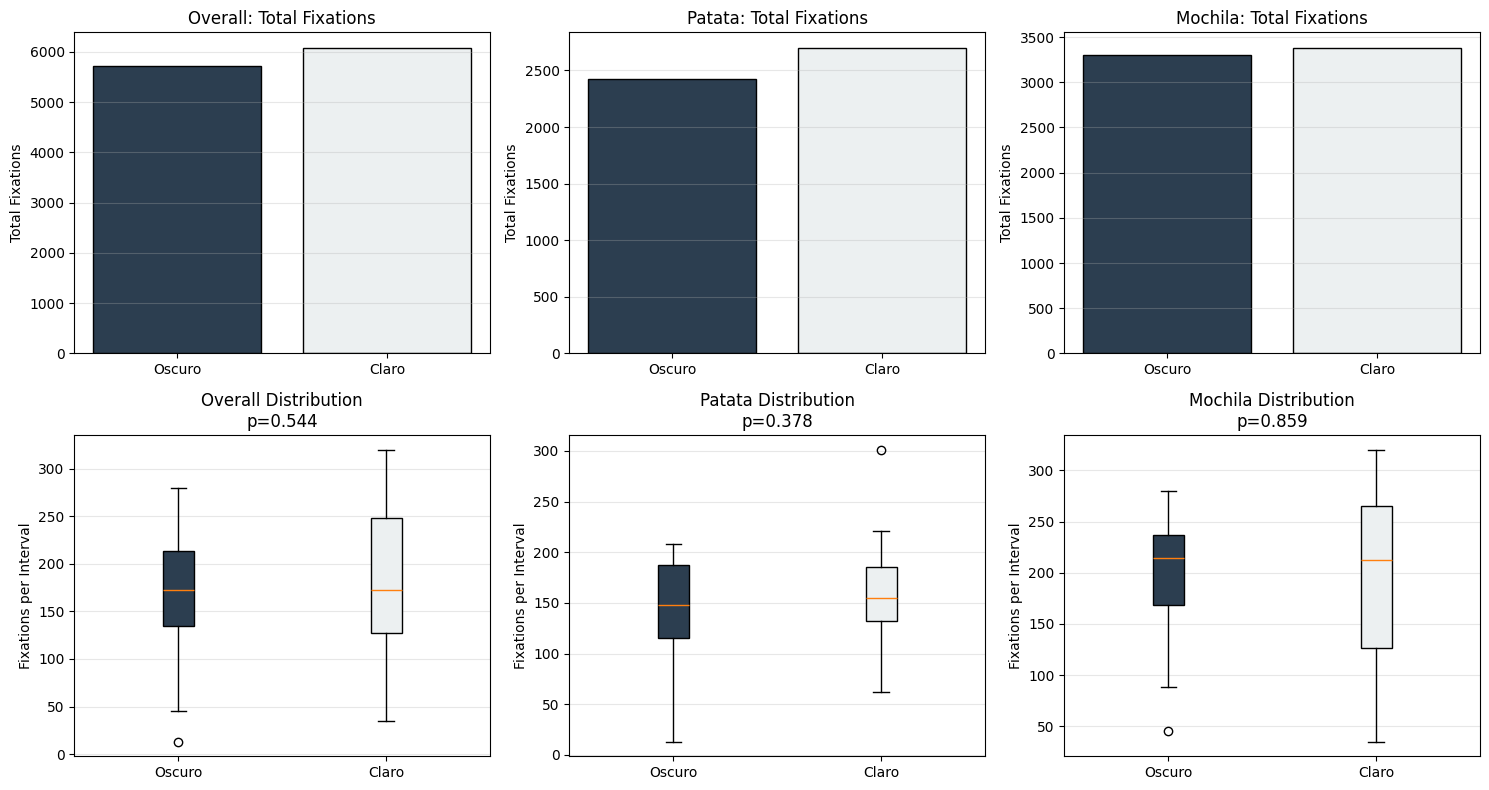

In [6]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2c3e50', '#ecf0f1']

# Bar chart
ax1.bar(['Oscuro', 'Claro'], [oscuro.sum(), claro.sum()], color=colors, edgecolor='black')
ax1.set_ylabel('Total Fixations')
ax1.set_title('Total Fixations: Oscuro vs Claro')
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2.boxplot([oscuro, claro], labels=['Oscuro', 'Claro'], patch_artist=True)
for patch, color in zip(ax2.artists, colors):
    patch.set_facecolor(color)
ax2.set_ylabel('Fixations per Interval')
ax2.set_title('Distribution')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/fixation_comparison_oscuro_vs_claro.png', dpi=300, bbox_inches='tight')
plt.show()